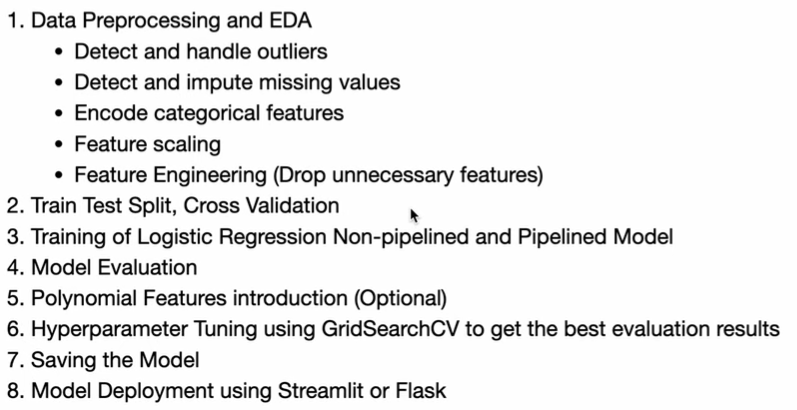

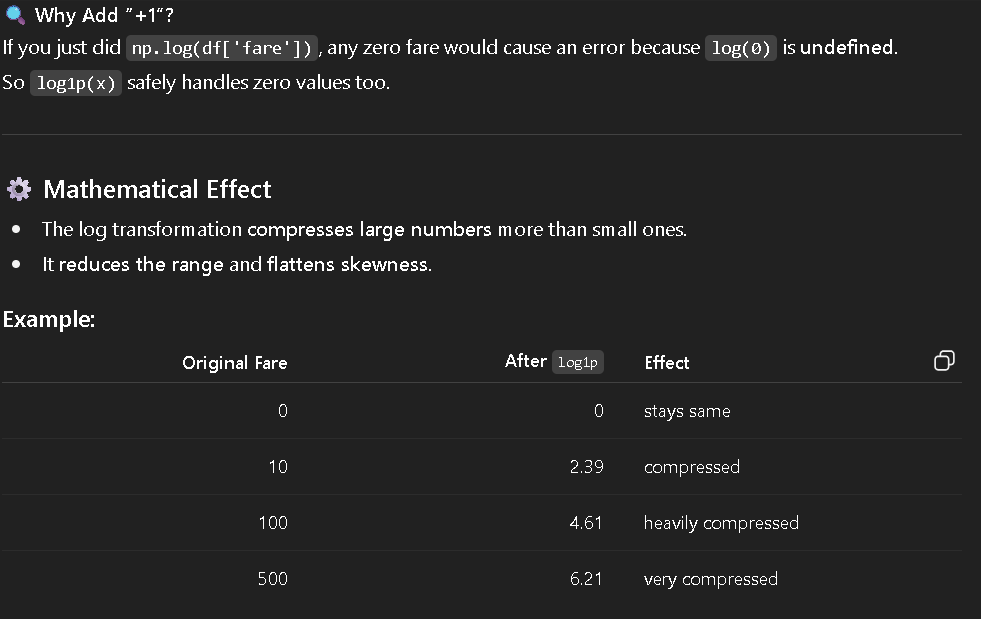

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, precision_score
)

df = pd.read_csv(r'D:\Codes\MachineLearning\Datasets\titanic.csv')

df.head()


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,target
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


In [4]:
df.isna().sum()

pclass          0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
target          0
dtype: int64

<Axes: ylabel='age'>

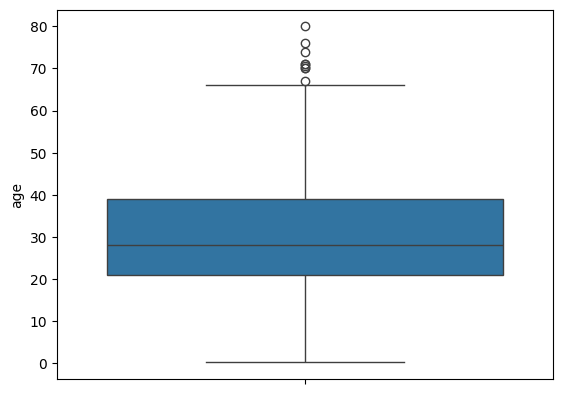

In [5]:
sns.boxplot(df['age'])

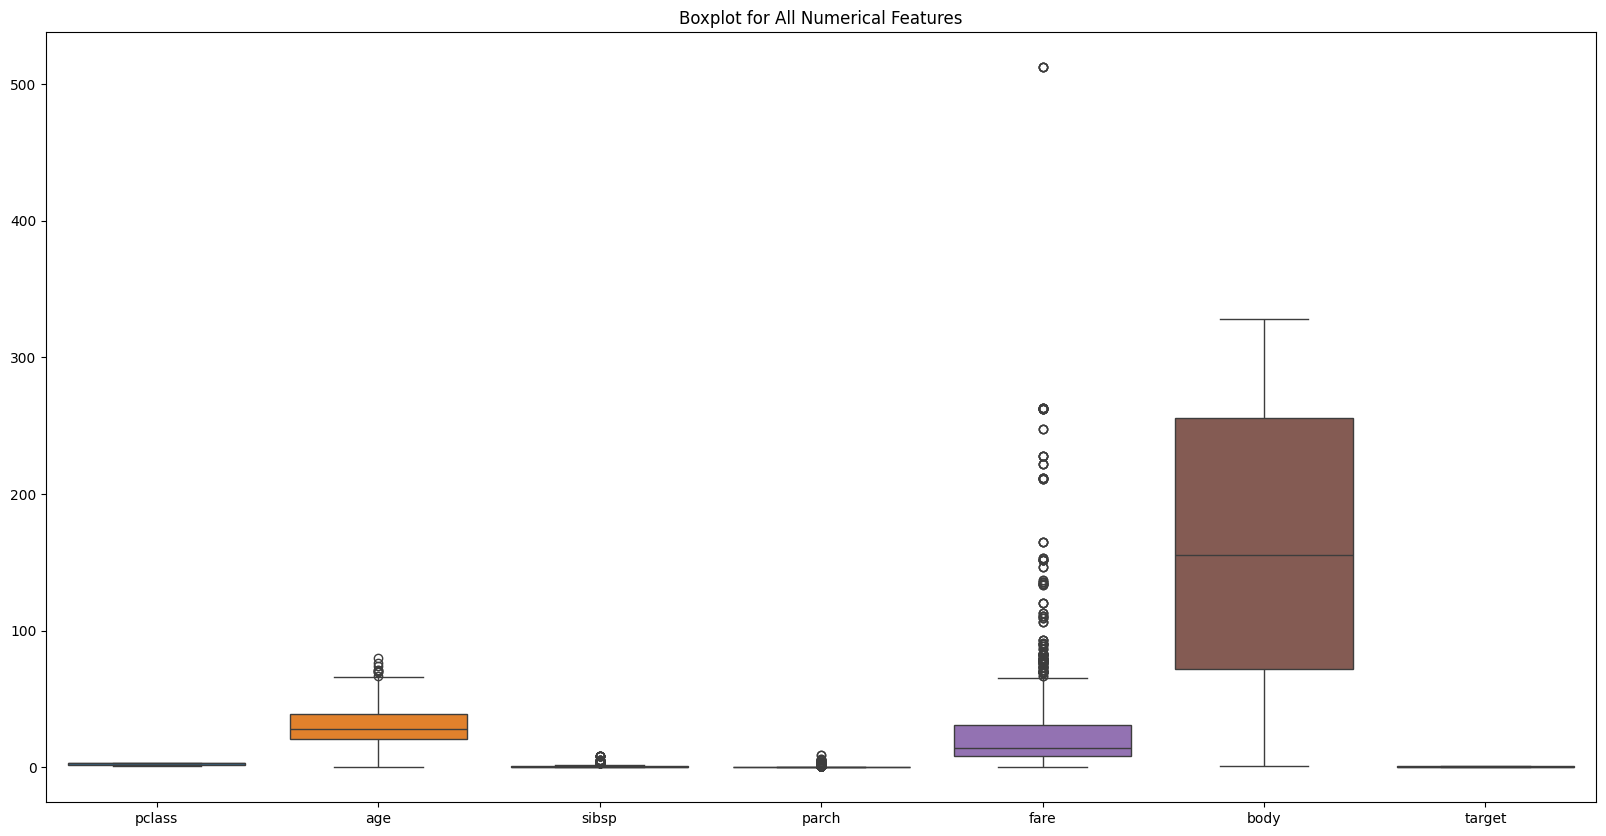

In [6]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df)
plt.title("Boxplot for All Numerical Features")
plt.show()

In [7]:
df.isna().sum()

pclass          0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
target          0
dtype: int64

In [8]:
df.columns

Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'boat', 'body', 'home.dest', 'target'],
      dtype='object')

<Axes: >

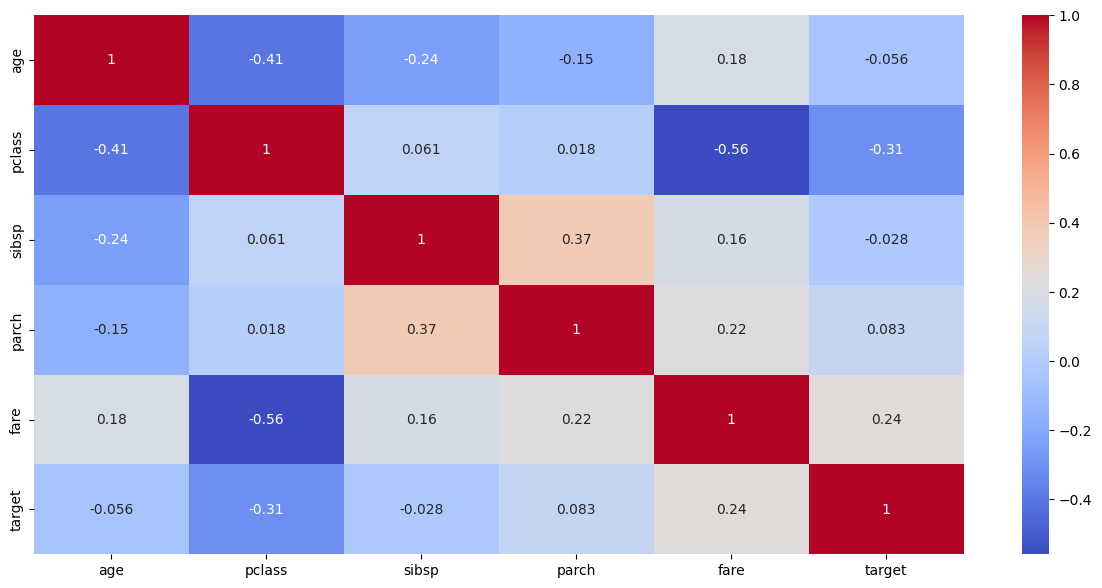

In [9]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[['age', 'pclass', 'sibsp', 'parch', 'fare', 'target']].corr(), annot=True, cmap='coolwarm')

In [10]:
df['pclass'].unique()

array([1, 2, 3])

In [11]:
# 'pclass', 'sex', 'embarked'
categorical_pipe = Pipeline(steps=[
    ('si', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# 'sibsp', 'parch' fixed Value
numeric_pipe = Pipeline(steps=[
    ('si', SimpleImputer(strategy='median')),
    ('sc', StandardScaler())
])

# 'age', 'fare' Continous Value
simple_numeric_pipe = Pipeline(steps=[
    ('si', SimpleImputer(strategy='median')),
    ('sc', StandardScaler())
])


In [12]:

preprocessing = ColumnTransformer(transformers=[
    ('cat', categorical_pipe, ['pclass', 'sex', 'embarked']),
    ('num', numeric_pipe, ['sibsp', 'parch']),
    ('cont', simple_numeric_pipe, ['age', 'fare'])
    ],
    remainder='drop'
)


In [13]:
model_pipe = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('regressor', LogisticRegression(class_weight='balanced', max_iter=1000))
])
model_pipe

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)

In [15]:
model_pipe.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
y_pred = model_pipe.predict(X_test)
y_pred

array([1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0])

In [17]:
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model_pipe.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81       163
           1       0.69      0.73      0.71        99

    accuracy                           0.77       262
   macro avg       0.76      0.76      0.76       262
weighted avg       0.77      0.77      0.77       262

ROC AUC: 0.8516762719216707


In [18]:
from sklearn.preprocessing import PolynomialFeatures
model_pipe = Pipeline([
    ('preprocessing', preprocessing),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('regressor', LogisticRegression(class_weight='balanced', max_iter=2000))
])


In [19]:
model_pipe.fit(X_train, y_train)


,steps,"[('preprocessing', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
model_pipe['regressor'].coef_


array([[ 0.38146404, -1.22200208, -2.42618784, -0.45730187, -0.51458724,
         0.75131225,  0.59904168,  0.09530099,  0.46102203,  0.        ,
        -1.30078378,  0.02711267, -0.90757845, -0.58398429,  0.95838435,
        -0.74775741, -0.39738685,  0.28007035, -0.04550705, -0.21657276,
        -0.90963898, -0.3721421 , -0.20975299,  1.52659165, -0.48830099,
        -0.06778112,  0.24173922,  0.1631355 , -0.40734657, -0.55216192,
         0.        , -0.09447107, -0.97702135,  0.15505506, -0.24089993,
        -0.4690796 , -0.71569504,  0.07096837, -0.07264944,  0.07556145,
         0.24559068, -0.31324677, -0.32171451, -0.12524647, -0.1468762 ]])

In [21]:
model_pipe['regressor'].intercept_

array([3.15688662])

In [22]:
prob = model_pipe.predict_proba(X_test)
prob


array([[4.66383195e-01, 5.33616805e-01],
       [9.43786220e-01, 5.62137798e-02],
       [2.02997459e-02, 9.79700254e-01],
       [1.43087643e-01, 8.56912357e-01],
       [5.34803346e-01, 4.65196654e-01],
       [9.05708755e-01, 9.42912453e-02],
       [2.81805317e-01, 7.18194683e-01],
       [2.78881320e-01, 7.21118680e-01],
       [7.49632216e-01, 2.50367784e-01],
       [5.27366065e-01, 4.72633935e-01],
       [3.29112099e-01, 6.70887901e-01],
       [8.66043210e-02, 9.13395679e-01],
       [7.96104593e-01, 2.03895407e-01],
       [6.15138398e-01, 3.84861602e-01],
       [8.09763907e-01, 1.90236093e-01],
       [3.38975697e-01, 6.61024303e-01],
       [4.65561048e-03, 9.95344390e-01],
       [7.04552736e-01, 2.95447264e-01],
       [4.23963935e-02, 9.57603607e-01],
       [3.99369586e-03, 9.96006304e-01],
       [3.04140751e-01, 6.95859249e-01],
       [7.68101746e-01, 2.31898254e-01],
       [1.25451800e-02, 9.87454820e-01],
       [8.67834476e-01, 1.32165524e-01],
       [7.893941

In [23]:
y_prob = prob[:,1]
y_prob

array([0.53361681, 0.05621378, 0.97970025, 0.85691236, 0.46519665,
       0.09429125, 0.71819468, 0.72111868, 0.25036778, 0.47263393,
       0.6708879 , 0.91339568, 0.20389541, 0.3848616 , 0.19023609,
       0.6610243 , 0.99534439, 0.29544726, 0.95760361, 0.9960063 ,
       0.69585925, 0.23189825, 0.98745482, 0.13216552, 0.21060583,
       0.18838724, 0.73654251, 0.99042097, 0.94590181, 0.47545529,
       0.22835869, 0.27707182, 0.45755375, 0.72541624, 0.178388  ,
       0.12687625, 0.42617926, 0.12803235, 0.49342893, 0.65531158,
       0.04007305, 0.49884413, 0.88479761, 0.19538092, 0.47435288,
       0.23694315, 0.21040454, 0.76374997, 0.99991735, 0.20345009,
       0.34770162, 0.5576097 , 0.17183845, 0.05408146, 0.16483247,
       0.86726882, 0.3744448 , 0.18691767, 0.69791385, 0.95622846,
       0.00876096, 0.23396976, 0.8326018 , 0.52156874, 0.97535502,
       0.310384  , 0.8278962 , 0.19947703, 0.25623486, 0.30358351,
       0.3693875 , 0.01200924, 0.99795077, 0.12258478, 0.31776

In [24]:
y_pred=np.array([1.0 if p > 0.5 else 0 for p in y_prob])
y_pred

array([1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1.,
       0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 1.,
       0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.,
       1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       0., 0., 1., 0., 0.

In [25]:
# Convert to numeric (0 and 1)
y_test = y_test.astype(int)
y_pred = y_pred.astype(int)


In [26]:
confusion_matrix(y_test,y_pred=y_pred)

array([[137,  26],
       [ 29,  70]])

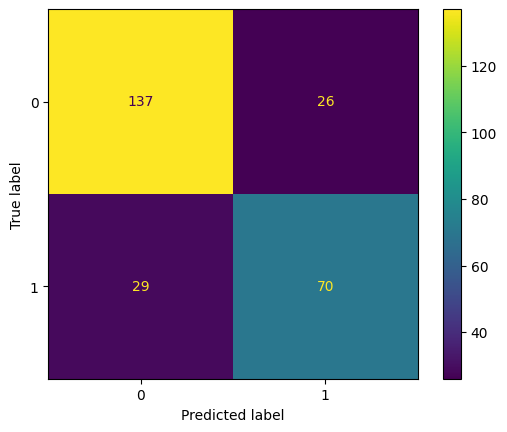

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [28]:
accuracy_score(y_test, y_pred)

0.7900763358778626

In [29]:
recall_score(y_test, y_pred)

0.7070707070707071

In [30]:
f1_score(y_test, y_pred)

0.717948717948718

In [31]:
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))
print("Defualt One ROC AUC:", roc_auc_score(y_test, model_pipe.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       163
           1       0.73      0.71      0.72        99

    accuracy                           0.79       262
   macro avg       0.78      0.77      0.78       262
weighted avg       0.79      0.79      0.79       262

ROC AUC: 0.7737807523083597
Defualt One ROC AUC: 0.8406457210138192


Precision Score: 0.7291666666666666
Recall Score: 0.7070707070707071


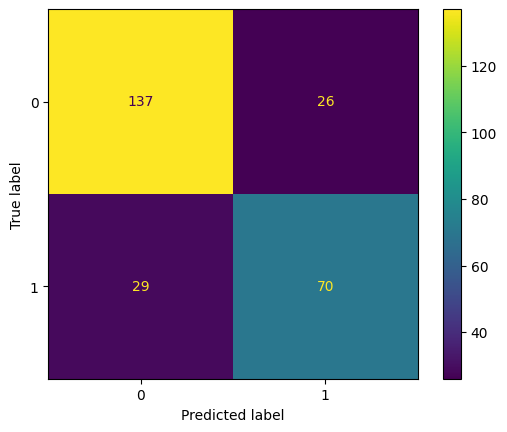

In [32]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred=y_pred))
disp.plot()

print("Precision Score:",precision_score(y_test, y_pred))
print("Recall Score:",recall_score(y_test, y_pred))


In [33]:
param_grid = {'regressor__C': np.logspace(-3, 3, 10)}
grid = GridSearchCV(model_pipe, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)
print(grid.best_params_, grid.best_score_)


{'regressor__C': np.float64(2.154434690031882)} 0.8526087185376591


In [34]:
fpr, tpr, threshold =  roc_curve(y_test, y_prob)
df1 = pd.DataFrame(zip(threshold, fpr, tpr),columns=['Threshold', 'FPR', 'TPR'])
df1

,Threshold,FPR,TPR
0,inf,0.000000,0.000000
1,0.999917,0.000000,0.010101
2,0.981099,0.000000,0.121212
3,0.981016,0.006135,0.121212
4,0.884798,0.006135,0.393939
...,...,...,...
87,0.060024,0.926380,0.969697
88,0.054081,0.926380,0.989899
89,0.042884,0.950920,0.989899
90,0.040073,0.950920,1.000000


In [35]:
df1 = df1.sort_values(by='Threshold', ascending=True)
df1


,Threshold,FPR,TPR
91,0.008761,1.000000,1.000000
90,0.040073,0.950920,1.000000
89,0.042884,0.950920,0.989899
88,0.054081,0.926380,0.989899
87,0.060024,0.926380,0.969697
...,...,...,...
4,0.884798,0.006135,0.393939
3,0.981016,0.006135,0.121212
2,0.981099,0.000000,0.121212
1,0.999917,0.000000,0.010101


In [36]:
model_auc = roc_auc_score(y_test, y_prob)
print('AUC Score: ',model_auc)

AUC Score:  0.8406457210138192


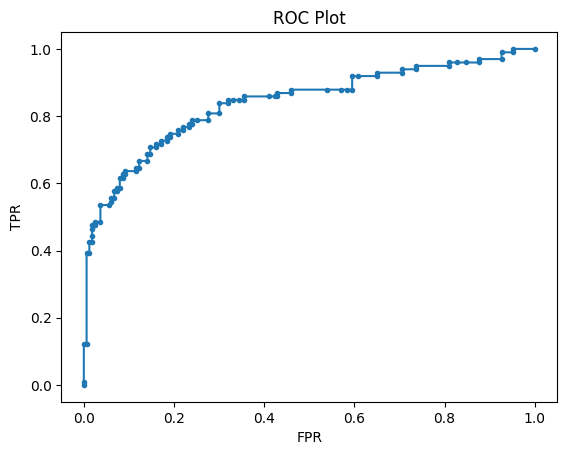

In [37]:
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, marker='.')
plt.title('ROC Plot')
plt.xlabel("FPR")
plt.ylabel('TPR')
plt.show()

In [38]:
model_pipe.fit(X,y)

,steps,"[('preprocessing', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
import joblib as jb
jb.dump(model_pipe,'Titanic.pkl')

['Titanic.pkl']

In [40]:
print("Model expects:", model_pipe['regressor'].n_features_in_, "features")


Model expects: 45 features


pclass, sex, age, sibsp, parch, fare, embarked